<a href="https://colab.research.google.com/github/Yashew/QuantumLeap-2026/blob/main/Classical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyscf


H2 (Hydrogen Gas)
Hartree-Fock Energy (initial geom): -1.11675931 Hartree
FCI Energy (initial geom): -1.13728383 Hartree
Execution time: 0.052520751953125 seconds
Correlation Energy (initial geom): -0.02052453 Hartree

Equilibrium Bond Distance (FCI): 0.759 Å
Minimum Energy at Equilibrium (FCI): -1.13684879 Hartree



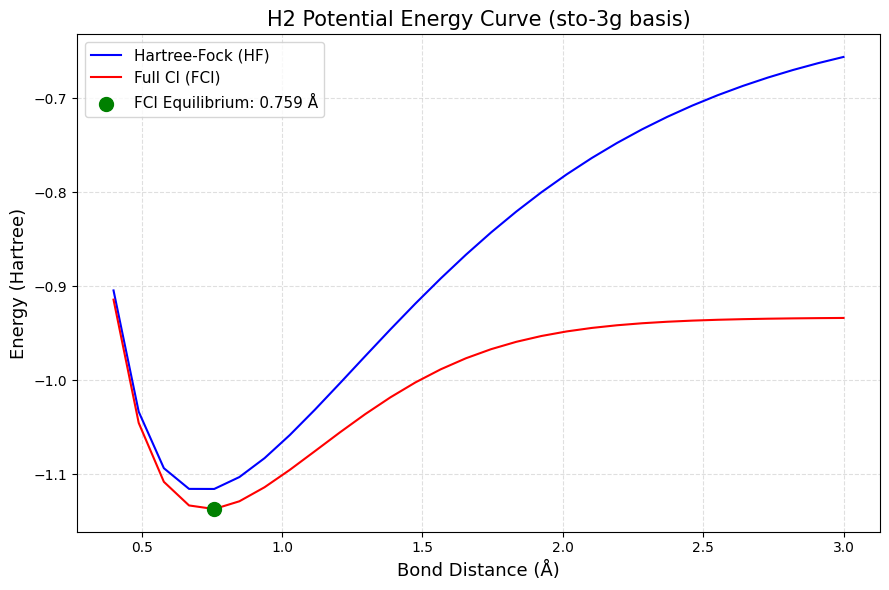

In [ ]:
# 1. HYDROGEN GAS (H2) - Potential Energy Curve
print("\n" + "=" * 30)
print("H2 (Hydrogen Gas)")
print("=" * 30)

start_time = time.time()

#1.Energy Calculation
# Define H2 molecule with an equilibrium bond length (approx. 0.74 Angstroms)
mol_h2 = gto.M(
    atom = 'H 0 0 0; H 0 0 0.74',
    basis = 'sto-3g',
    verbose = 0,
    spin = 0,
    charge = 0)

mf_h2 = scf.RHF(mol_h2)
hf_energy_h2 = mf_h2.kernel()



print(f"Hartree-Fock Energy (initial geom): {hf_energy_h2:.8f} Hartree")



# Perform Full Configuration Interaction (FCI)
cisolver_h2 = fci.FCI(mf_h2)
e_fci_h2, _ = cisolver_h2.kernel()
print(f"FCI Energy (initial geom): {e_fci_h2:.8f} Hartree")

end_time = time.time()
print("Execution time:", end_time - start_time, "seconds")

# Calculate correlation energy
corr_energy_h2 = e_fci_h2 - hf_energy_h2
print(f"Correlation Energy (initial geom): {corr_energy_h2:.8f} Hartree\n")

# 2.Calculate Potential Energy Curve (PEC)
# Define a range of H-H bond distances to scan
bond_distances = np.linspace(0.4, 3.0, 30)

hf_energies = []
fci_energies = []

# Loop through each bond distance to calculate energies
for r in bond_distances:
    # Define H2 molecule with current bond distance
    mol = gto.M(atom=f'H 0 0 0; H 0 0 {r}',
                basis='sto-3g',
                verbose=0,
                spin=0, # Singlet state
                charge=0)

    # Perform Hartree-Fock calculation for the current geometry
    mf = scf.RHF(mol).run()
    hf_energies.append(mf.e_tot)

    # Perform FCI calculation for the current geometry
    cisolver = fci.FCI(mf)
    e_fci, _ = cisolver.kernel()
    fci_energies.append(e_fci)

# 3. Find Equilibrium Bond Distance and Energy from FCI curve
# The equilibrium point is where the energy is minimized
min_energy_idx = np.argmin(fci_energies)
r_eq_h2 = bond_distances[min_energy_idx]
e_eq_h2 = fci_energies[min_energy_idx]

print(f"Equilibrium Bond Distance (FCI): {r_eq_h2:.3f} Å")
print(f"Minimum Energy at Equilibrium (FCI): {e_eq_h2:.8f} Hartree\n")

# 4. Plotting the Potential Energy Curves
plt.figure(figsize=(9, 6)) # Set a larger figure size for better visualization

# Plot Hartree-Fock energies
plt.plot(bond_distances, hf_energies, 'bo-', label='Hartree-Fock (HF)', markersize=0, linewidth=1.5)

# Plot FCI energies
plt.plot(bond_distances, fci_energies, 'ro-', label='Full CI (FCI)', markersize=0, linewidth=1.5)

# Mark the equilibrium point found from FCI
plt.scatter([r_eq_h2], [e_eq_h2], color='green', s=100, zorder=5,
            label=f'FCI Equilibrium: {r_eq_h2:.3f} Å')

# Add plot labels and title
plt.xlabel('Bond Distance (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('H2 Potential Energy Curve (sto-3g basis)', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, linestyle='--') # Add a finer grid
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()




LiH (Lithium Hydride)
Hartree-Fock Energy (initial geom): -7.86202386 Hartree
FCI Energy (initial geom): -7.88240193 Hartree
Correlation Energy (initial geom): -0.03501918 Hartree

Equilibrium Bond Distance (FCI): 1.573 Å
Minimum Energy at Equilibrium (FCI): -7.88265326 Hartree



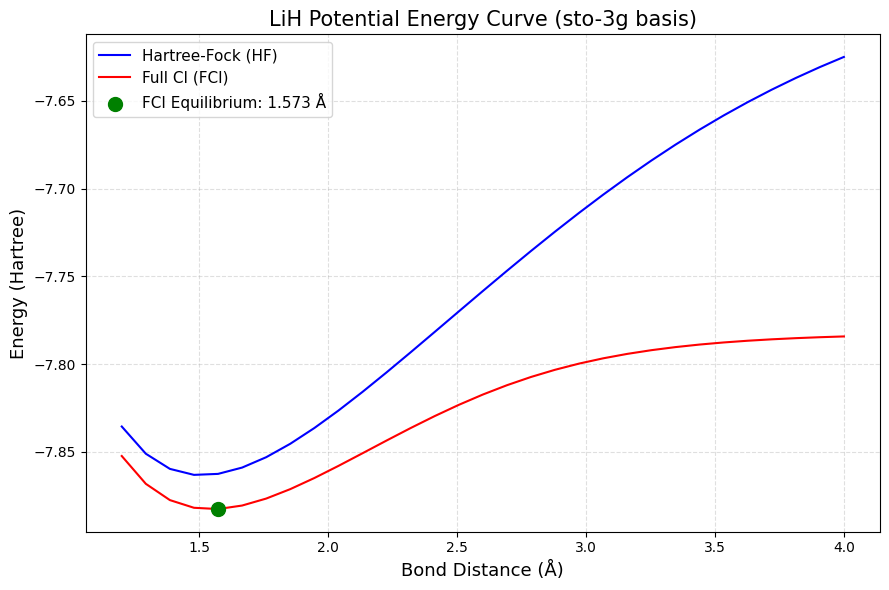

Execution time: 0.14371943473815918 seconds


In [ ]:
# 2. LITHIUM HYDRIDE (LiH) - Potential Energy Curve

print("\n" + "=" * 30)
print("LiH (Lithium Hydride)")
print("=" * 30)

start_time = time.time()

# 1.Energy Calculation
# Define LiH molecule with an equilibrium bond length (approx. 1.595 Angstroms)
mol_lih_initial = gto.M(
    atom = 'Li 0 0 0; H 0 0 1.595',
    basis = 'sto-3g',
    verbose = 0,
    spin = 0,
    charge = 0
)

# Perform Hartree-Fock (HF) calculation for the initial geometry
mf_lih_initial = scf.RHF(mol_lih_initial)
hf_energy_lih_initial = mf_lih_initial.kernel()
print(f"Hartree-Fock Energy (initial geom): {hf_energy_lih_initial:.8f} Hartree")

# Perform Full Configuration Interaction (FCI)
cisolver_lih = fci.FCI(mf_lih_initial) #MOs and other info from hf is used as starting point
e_fci_lih, _ = cisolver_lih.kernel()
print(f"FCI Energy (initial geom): {e_fci_lih:.8f} Hartree")

# Calculate correlation energy for the initial geometry
corr_beh2_initial = e_fci_beh2_initial - hf_energy_beh2_initial
print(f"Correlation Energy (initial geom): {corr_beh2_initial:.8f} Hartree\n")

# 2. Calculate Potential Energy Curve (PEC)
# Define a range of Li-H bond distances to scan
bond_distances = np.linspace(1.2, 4.0, 31)  # From 1.2 to 4.0 Angstroms, 31 points

hf_energies = [] # List to store HF energies for different bond distances
fci_energies = [] # List to store FCI energies for different bond distances

end_time = time.time()

# Loop through each bond distance to calculate energies
for r in bond_distances:
    # Define LiH molecule with current bond distance
    mol = gto.M(atom=f'Li 0 0 0; H {r} 0 0',
                basis='sto-3g',
                verbose=0)

    # Perform Hartree-Fock calculation for the current geometry
    mf = scf.RHF(mol).run()
    hf_energies.append(mf.e_tot)

    # Perform FCI calculation for the current geometry
    cisolver = fci.FCI(mf)
    e_fci, _ = cisolver.kernel()
    fci_energies.append(e_fci)

# 3. Find Equilibrium Bond Distance and Energy from FCI curve
# The equilibrium point is where the energy is minimized
min_energy_idx = np.argmin(fci_energies)
r_eq_lih = bond_distances[min_energy_idx]
e_eq_lih = fci_energies[min_energy_idx]

print(f"Equilibrium Bond Distance (FCI): {r_eq_lih:.3f} Å")
print(f"Minimum Energy at Equilibrium (FCI): {e_eq_lih:.8f} Hartree\n")

# 4. Plotting the Potential Energy Curves
plt.figure(figsize=(9, 6)) # Set a larger figure size for better visualization

# Plot Hartree-Fock energies
plt.plot(bond_distances, hf_energies, 'bo-', label='Hartree-Fock (HF)', markersize=0, linewidth=1.5)

# Plot FCI energies
plt.plot(bond_distances, fci_energies, 'ro-', label='Full CI (FCI)', markersize=0, linewidth=1.5)

# Mark the equilibrium point found from FCI
plt.scatter([r_eq_lih], [e_eq_lih], color='green', s=100, zorder=5,
            label=f'FCI Equilibrium: {r_eq_lih:.3f} Å')

plt.xlabel('Bond Distance (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('LiH Potential Energy Curve (sto-3g basis)', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

print("Execution time:", end_time - start_time, "seconds")


BeH2 (Beryllium Hydride)
Hartree-Fock Energy (initial geom): -15.56009838 Hartree
FCI Energy (initial geom): -15.59511756 Hartree
Correlation Energy (initial geom): -0.03501918 Hartree

Equilibrium Bond Distance (FCI): 2.676 Å
Minimum Energy at Equilibrium (FCI): -15.59492491 Hartree



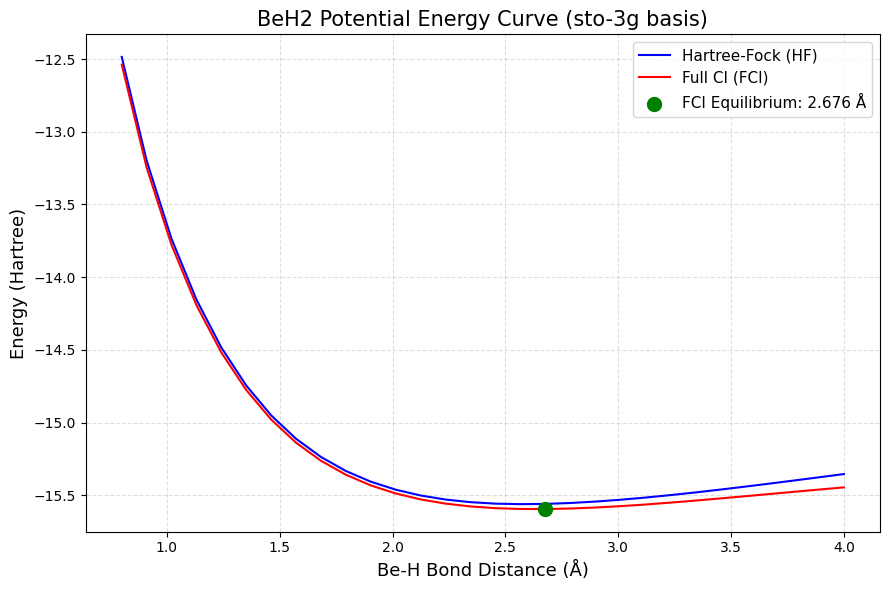

Execution time: 0.16538310050964355 seconds


In [ ]:
# 3. BERYLLIUM HYDRIDE (BeH2) - Potential Energy Curve

print("\n" + "=" * 30)
print("BeH2 (Beryllium Hydride)")
print("=" * 30)

start_time = time.time()

# 1. Initial Single-Point Calculation for a reference geometry
# Define BeH2 molecule with an equilibrium geometry (linear, bond length 1.33 Angstroms)
mol_beh2_initial = gto.M(
    atom = 'H -1.33 0 0; Be 0 0 0; H 1.33 0 0', # Example equilibrium geometry
    basis = 'sto-3g',                           # Minimal basis for computational efficiency
    verbose = 0,                                # Suppress detailed output
    spin = 0,                                   # Singlet state (closed shell)
    charge = 0
)


# Perform Hartree-Fock (HF) calculation for the initial geometry
mf_beh2_initial = scf.RHF(mol_beh2_initial)
hf_energy_beh2_initial = mf_beh2_initial.kernel()


print(f"Hartree-Fock Energy (initial geom): {hf_energy_beh2_initial:.8f} Hartree")

# Perform Full Configuration Interaction (FCI) for the initial geometry
# FCI is exact within the chosen basis set
cisolver_beh2_initial = fci.FCI(mf_beh2_initial)
e_fci_beh2_initial, _ = cisolver_beh2_initial.kernel()
print(f"FCI Energy (initial geom): {e_fci_beh2_initial:.8f} Hartree")

# Calculate correlation energy for the initial geometry
corr_beh2_initial = e_fci_beh2_initial - hf_energy_beh2_initial
print(f"Correlation Energy (initial geom): {corr_beh2_initial:.8f} Hartree\n")

end_time = time.time()

# 2. Calculate Potential Energy Curve (PEC)
# Define a range of Be-H bond distances to scan
bond_distances = np.linspace(0.8, 4.0, 30) # From 0.8 to 4.0 Angstroms, 30 points

hf_energies_beh2 = [] # List to store HF energies for different bond distances
fci_energies_beh2 = [] # List to store FCI energies for different bond distances

# Loop through each bond distance to calculate energies
for r in bond_distances:
    # Define BeH2 molecule (linear geometry, varying Be-H bond distance)
    # The Be atom is at the origin, and H atoms are at -r/2 and +r/2 along x-axis
    mol = gto.M(atom=f'H 0 0 {-r/2}; Be 0 0 0; H 0 0 {r/2}',
                basis='sto-3g', # Same minimal basis as initial calculation
                verbose=0,
                spin=0,         # Singlet state
                charge=0)

    # Perform Hartree-Fock calculation for the current geometry
    mf = scf.RHF(mol).run()
    hf_energies_beh2.append(mf.e_tot)

    # Perform FCI calculation for the current geometry
    cisolver = fci.FCI(mf)
    e_fci, _ = cisolver.kernel()
    fci_energies_beh2.append(e_fci)

# 3. Find Equilibrium Bond Distance and Energy from FCI curve
# The equilibrium point is where the energy is minimized
min_energy_idx = np.argmin(fci_energies_beh2)
r_eq_beh2 = bond_distances[min_energy_idx]
e_eq_beh2 = fci_energies_beh2[min_energy_idx]

print(f"Equilibrium Bond Distance (FCI): {r_eq_beh2:.3f} Å")
print(f"Minimum Energy at Equilibrium (FCI): {e_eq_beh2:.8f} Hartree\n")

# 4. Plotting the Potential Energy Curves
plt.figure(figsize=(9, 6)) # Set a larger figure size for better visualization

# Plot Hartree-Fock energies
plt.plot(bond_distances, hf_energies_beh2, 'bo-', label='Hartree-Fock (HF)', markersize=0, linewidth=1.5)

# Plot FCI energies
plt.plot(bond_distances, fci_energies_beh2, 'ro-', label='Full CI (FCI)', markersize=0, linewidth=1.5)

# Mark the equilibrium point found from FCI
plt.scatter([r_eq_beh2], [e_eq_beh2], color='green', s=100, zorder=5,
            label=f'FCI Equilibrium: {r_eq_beh2:.3f} Å')

plt.xlabel('Be-H Bond Distance (Å)', fontsize=13)
plt.ylabel('Energy (Hartree)', fontsize=13)
plt.title('BeH2 Potential Energy Curve (sto-3g basis)', fontsize=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()
print("Execution time:", end_time - start_time, "seconds")

In [ ]:
#C2H6

start_time = time.time()

# Define C2H6 molecule
mol_ethane_simple = gto.M(
    atom = '''
    C     0.0000    0.0000    0.0000
    C     0.0000    0.0000    1.5400
    H     0.0000    1.0200   -0.3800
    H    -0.8830   -0.5100   -0.3800
    H     0.8830   -0.5100   -0.3800
    H     0.0000    1.0200    1.9200
    H    -0.8830   -0.5100    1.9200
    H     0.8830   -0.5100    1.9200
    ''',
    basis = 'sto-3g',
    verbose = 0,
    spin = 0,
    charge = 0
)

# Hartree-Fock calculation
mf_ethane_simple = scf.RHF(mol_ethane_simple)
hf_energy_ethane_simple = mf_ethane_simple.kernel()

end_time = time.time()

print(f"Ethane Hartree-Fock Energy: {hf_energy_ethane_simple:.8f} Hartree")
print("Execution time:", end_time - start_time, "seconds")


Ethane Hartree-Fock Energy: -78.30125880 Hartree
Execution time: 0.1874074935913086 seconds


In [ ]:
print("\n" + "=" * 30)
print("Extracted Energies")
print("=" * 30)

# 1. Access Hartree-Fock (HF) energies
hf_h2_energy_extracted = hf_energy_h2
hf_lih_energy_extracted = hf_energy_lih_initial
hf_beh2_energy_extracted = hf_energy_beh2_initial
hf_c2h6_energy_extracted = hf_energy_ethane_simple

# 2. Access Full Configuration Interaction (FCI) energies
fci_h2_energy_extracted = e_fci_h2
fci_lih_energy_extracted = e_fci_lih
fci_beh2_energy_extracted = e_fci_beh2_initial

# Print the extracted energies
print(f"H2 HF Energy: {hf_h2_energy_extracted:.8f} Hartree")
print(f"H2 FCI Energy: {fci_h2_energy_extracted:.8f} Hartree\n")

print(f"LiH HF Energy: {hf_lih_energy_extracted:.8f} Hartree")
print(f"LiH FCI Energy: {fci_lih_energy_extracted:.8f} Hartree\n")

print(f"BeH2 HF Energy: {hf_beh2_energy_extracted:.8f} Hartree")
print(f"BeH2 FCI Energy: {fci_beh2_energy_extracted:.8f} Hartree\n")

print(f"C2H6 HF Energy: {hf_c2h6_energy_extracted:.8f} Hartree\n")



Extracted Energies
H2 HF Energy: -1.11675931 Hartree
H2 FCI Energy: -1.13728383 Hartree

LiH HF Energy: -7.86202386 Hartree
LiH FCI Energy: -7.88240193 Hartree

BeH2 HF Energy: -15.56009838 Hartree
BeH2 FCI Energy: -15.59511756 Hartree

C2H6 HF Energy: -78.30125880 Hartree



In [ ]:
import pandas as pd

# Calculate correlation energies where FCI was performed
corr_h2 = fci_h2_energy_extracted - hf_h2_energy_extracted
corr_lih = fci_lih_energy_extracted - hf_lih_energy_extracted
corr_beh2 = fci_beh2_energy_extracted - hf_beh2_energy_extracted

# Create a list of dictionaries for the data
data = [
    {
        'Molecule': 'H2',
        'HF Energy (Hartree)': hf_h2_energy_extracted,
        'FCI Energy (Hartree)': fci_h2_energy_extracted,
        'Correlation Energy (Hartree)': corr_h2
    },
    {
        'Molecule': 'LiH',
        'HF Energy (Hartree)': hf_lih_energy_extracted,
        'FCI Energy (Hartree)': fci_lih_energy_extracted,
        'Correlation Energy (Hartree)': corr_lih
    },
    {
        'Molecule': 'BeH2',
        'HF Energy (Hartree)': hf_beh2_energy_extracted,
        'FCI Energy (Hartree)': fci_beh2_energy_extracted,
        'Correlation Energy (Hartree)': corr_beh2
    },
    {
        'Molecule': 'C2H6',
        'HF Energy (Hartree)': hf_c2h6_energy_extracted,
        'FCI Energy (Hartree)': 'N/A',
        'Correlation Energy (Hartree)': 'N/A'
    }
]

# Create the pandas DataFrame
comparison_table = pd.DataFrame(data)

print("\n" + "=" * 30)
print("Energy Comparison Table")
print("=" * 30)
print(comparison_table.to_markdown(index=False))

print("FCI Energy calculation for C2H6 is too computationally expensive")



Energy Comparison Table
| Molecule   |   HF Energy (Hartree) | FCI Energy (Hartree)   | Correlation Energy (Hartree)   |
|:-----------|----------------------:|:-----------------------|:-------------------------------|
| H2         |              -1.11676 | -1.1372838344885023    | -0.02052452709207686           |
| LiH        |              -7.86202 | -7.882401932290221     | -0.02037807216310128           |
| BeH2       |             -15.5601  | -15.595117562572986    | -0.03501918157508044           |
| C2H6       |             -78.3013  | N/A                    | N/A                            |
FCI Energy calculation for C2H6 is too computationally expensive
